# BiomedParse Fascia+Vein Fine-Tuning

Continues training from the **epoch-10 fascia checkpoint** (`fascia_finetuning_v2_production`) and adds vein detection.

## Strategy
- Start from the already-trained fascia model (epoch 10, Train IoU=0.784, Test IoU=0.679)
- Restore both fascia (category_id=17) **and** vein (category_id=18) annotations
- Lower LR (5e-5 vs 1e-4) so fascia knowledge is not overwritten
- Save to `output/fascia_vein_finetuning`

## Requirements
- `finetune_biomedparse_v2.ipynb` must have been run (fascia checkpoint + backup JSONs must exist)
- Vein mask files must be present in `train_mask/` and `test_mask/`

---
## 1 · Setup

In [1]:
import os
import sys
import json
import shutil
import subprocess
from pathlib import Path

_NB_DIR     = Path(os.path.abspath(''))
_BASE_DIR   = _NB_DIR
BIOMEDPARSE = _BASE_DIR / 'BiomedParse'
FASCIA_DATA = BIOMEDPARSE / 'biomedparse_datasets' / 'Fascia_Detection'

sys.path.insert(0, str(_BASE_DIR / 'stubs'))
sys.path.insert(0, str(BIOMEDPARSE))

# Exact epoch-10 fascia checkpoint (last checkpoint from v2_production run_3)
FASCIA_CKPT = (
    BIOMEDPARSE / 'output' / 'fascia_finetuning_v2_production' /
    'biomed_fascia_finetuning.yaml_conf~' / 'run_3' / '00001470' /
    'default' / 'model_state_dict.pt'
)

print(f'Base dir:    {_BASE_DIR}')
print(f'BiomedParse: {BIOMEDPARSE}')
print(f'Fascia data: {FASCIA_DATA}')
print(f'Fascia ckpt: {FASCIA_CKPT}')

assert FASCIA_DATA.exists(), f'Dataset dir not found: {FASCIA_DATA}'
assert (FASCIA_DATA / 'train_with_veins_backup.json').exists(), \
    'Backup JSON not found — run the filter cell in finetune_biomedparse_v2.ipynb first'
assert FASCIA_CKPT.exists(), \
    f'Fascia checkpoint not found — run v2 training first:\n  {FASCIA_CKPT}'
print('All paths OK.')

Base dir:    c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection
BiomedParse: c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse
Fascia data: c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection
Fascia ckpt: c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\output\fascia_finetuning_v2_production\biomed_fascia_finetuning.yaml_conf~\run_3\00001470\default\model_state_dict.pt
All paths OK.


---
## 2 · Restore combined dataset (fascia + vein)

The v2 notebook filtered to fascia-only. Here we restore both category_id=17 (fascia) and 18 (vein).

In [2]:
def restore_combined(json_path: Path) -> dict:
    backup = json_path.with_name(json_path.stem + '_with_veins_backup' + json_path.suffix)
    assert backup.exists(), f'Backup not found: {backup}'
    shutil.copy(backup, json_path)
    with open(json_path) as f:
        d = json.load(f)
    fascia = sum(1 for a in d['annotations'] if a['category_id'] == 17)
    vein   = sum(1 for a in d['annotations'] if a['category_id'] == 18)
    print(f'  {json_path.name}: {fascia} fascia + {vein} vein ({fascia+vein} total)')
    return d

print('Restoring combined dataset...')
train_data = restore_combined(FASCIA_DATA / 'train.json')
test_data  = restore_combined(FASCIA_DATA / 'test.json')
print()
print(f'Training on {len(train_data["annotations"])} total annotations')
print(f'Testing on  {len(test_data["annotations"])} total annotations')

Restoring combined dataset...
  train.json: 2364 fascia + 1731 vein (4095 total)
  test.json: 415 fascia + 305 vein (720 total)

Training on 4095 total annotations
Testing on  720 total annotations


---
## 3 · Verify vein mask files exist

In [3]:
import numpy as np
from PIL import Image

TRAIN_MASK_DIR = FASCIA_DATA / 'train_mask'
TEST_MASK_DIR  = FASCIA_DATA / 'test_mask'

vein_train_anns = [a for a in train_data['annotations'] if a['category_id'] == 18]
vein_test_anns  = [a for a in test_data['annotations']  if a['category_id'] == 18]

train_missing = [a for a in vein_train_anns if not (TRAIN_MASK_DIR / a['mask_file']).exists()]
test_missing  = [a for a in vein_test_anns  if not (TEST_MASK_DIR  / a['mask_file']).exists()]

print(f'Vein train: {len(vein_train_anns)} annotations, {len(train_missing)} missing mask files')
print(f'Vein test:  {len(vein_test_anns)} annotations, {len(test_missing)} missing mask files')

if train_missing or test_missing:
    print('\nWARNING: Missing mask files:')
    for a in (train_missing + test_missing)[:5]:
        print(f'  {a["mask_file"]}')
else:
    print('All vein mask files present.')

# Inspect a sample vein mask to verify pixel values
if vein_train_anns:
    sample_ann  = vein_train_anns[0]
    sample_path = TRAIN_MASK_DIR / sample_ann['mask_file']
    if sample_path.exists():
        mask_arr = np.array(Image.open(sample_path).convert('L'))
        print(f'\nSample vein mask: shape={mask_arr.shape}, unique values={np.unique(mask_arr).tolist()}')
        print(f'Vein pixels (val==1): {(mask_arr == 1).sum()}')

Vein train: 1731 annotations, 0 missing mask files
Vein test:  305 annotations, 0 missing mask files
All vein mask files present.

Sample vein mask: shape=(1024, 1024), unique values=[0, 1]
Vein pixels (val==1): 7152


---
## 4 · Train (fascia+vein, starting from fascia epoch-10 checkpoint)

Key differences from v2:
- `SOLVER.BASE_LR 0.00005` — half of v2 to preserve fascia knowledge  
- `RESUME_FROM` points to fascia epoch-10 checkpoint  
- `SAVE_DIR output/fascia_vein_finetuning`  
- Training data has both fascia and vein annotations

In [4]:
import re

env = dict(os.environ)
env['DETECTRON2_DATASETS'] = str(BIOMEDPARSE / 'biomedparse_datasets')
env['DATASET']             = str(BIOMEDPARSE / 'biomedparse_datasets')
env['DATASET2']            = str(BIOMEDPARSE / 'biomedparse_datasets')
env['VLDATASET']           = str(BIOMEDPARSE / 'biomedparse_datasets')
env['PYTHONPATH'] = (
    str(_BASE_DIR / 'stubs') + os.pathsep +
    str(BIOMEDPARSE)        + os.pathsep +
    env.get('PYTHONPATH', '')
)
env['PYTHONUTF8'] = '1'

cmd = [
    sys.executable, '-u', 'entry.py', 'train',
    '--conf_files', 'configs/biomed_fascia_finetuning.yaml',
    '--overrides',
    'FP16',                           'True',
    'RANDOM_SEED',                    '2024',
    'BioMed.INPUT.IMAGE_SIZE',        '512',
    'TRAIN.BATCH_SIZE_TOTAL',         '16',
    'TRAIN.BATCH_SIZE_PER_GPU',       '16',
    'SOLVER.MAX_NUM_EPOCHS',          '10',
    'SOLVER.BASE_LR',                 '0.00005',
    'SOLVER.FIX_PARAM.backbone',      'True',
    'SOLVER.FIX_PARAM.lang_encoder',  'True',
    'SOLVER.FIX_PARAM.pixel_decoder', 'False',
    'WEIGHT',                         'True',
    'LOG_EVERY',                      '1',
    'RESUME_FROM',  str(FASCIA_CKPT),
    'SAVE_DIR',     'output/fascia_vein_finetuning',
]

print('=' * 65)
print('FASCIA+VEIN | Continuing from fascia epoch-10 | LR=5e-5 | 10 epochs')
print('Early stopping: patience=2 epochs, min_delta=0.005')
print(f'Resuming: {FASCIA_CKPT.name}  (run_3/00001470)')
print('Checkpoints -> BiomedParse/output/fascia_vein_finetuning/')
print('=' * 65, flush=True)

proc = subprocess.Popen(
    cmd,
    cwd=str(BIOMEDPARSE),
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding='utf-8',
    errors='replace',
)

PATIENCE    = 2
MIN_DELTA   = 0.005
best_iou    = 0.0
no_improve  = 0
current_iou = 0.0

for line in proc.stdout:
    print(line, end='', flush=True)
    hit = re.search(r'~IoU.grd.=([0-9.]+)', line)
    if hit:
        current_iou = float(hit.group(1))
    if 'PROGRESS:' in line:
        if current_iou > best_iou + MIN_DELTA:
            best_iou   = current_iou
            no_improve = 0
            print(f'[early stop] improved -> best={best_iou:.4f}', flush=True)
        else:
            no_improve += 1
            print(f'[early stop] no improvement {no_improve}/{PATIENCE} (best={best_iou:.4f})', flush=True)
            if no_improve >= PATIENCE:
                print('[early stop] terminating.', flush=True)
                proc.terminate()
                break

proc.wait()
print(f'\nDone — exit {proc.returncode} | best oracle IoU = {best_iou:.4f}')

FASCIA+VEIN | Continuing from fascia epoch-10 | LR=5e-5 | 10 epochs
Early stopping: patience=2 epochs, min_delta=0.005
Resuming: model_state_dict.pt  (run_3/00001470)
Checkpoints -> BiomedParse/output/fascia_vein_finetuning/
Random seed set as 2024
INFO:trainer.distributed_trainer:Setting SAVE_DIR as output\fascia_vein_finetuning
INFO:trainer.distributed_trainer:Using CUDA
INFO:trainer.distributed_trainer:Save config file to output\fascia_vein_finetuning\conf_copy.yaml
INFO:trainer.distributed_trainer:Base learning rate: 5e-05
INFO:trainer.distributed_trainer:Number of GPUs: 1
INFO:trainer.distributed_trainer:Gradient accumulation steps: 1
INFO:trainer.default_trainer:Imported base_dir at base_path ./
c:\Users\Krish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layer

---
## 5 · Plot IoU per epoch

In [5]:
import json as _json
import re as _re
import matplotlib.pyplot as plt

with open('finetune_biomedparse_vein.ipynb', encoding='utf-8') as f:
    nb = _json.load(f)

text = ''
for cell in nb['cells']:
    if cell.get('id') == 'vein-train':
        for out in cell.get('outputs', []):
            text += ''.join(out.get('text', ''))
        break

lines = _re.split(r'[\r\n]', text)
iou_by_epoch = {}
current_epoch = None
for line in lines:
    m = _re.search(r'Epoch (\d+)/\d+', line)
    if m:
        current_epoch = int(m.group(1))
    m = _re.search(r'~IoU\(grd\)=([0-9.]+)', line)
    if m and current_epoch:
        iou_by_epoch[current_epoch] = float(m.group(1))

if not iou_by_epoch:
    print('No IoU values found — run training cell first.')
else:
    epochs = sorted(iou_by_epoch)
    ious   = [iou_by_epoch[e] for e in epochs]

    print(f'{"Epoch":>6}  {"IoU(grd)":>10}')
    print('-' * 20)
    for e, iou in zip(epochs, ious):
        print(f'{e:>6}  {iou:>10.4f}')
    print(f'\nBest: {max(ious):.4f}  (epoch {epochs[ious.index(max(ious))]})')

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, ious, marker='o', linewidth=2, label='Fascia+Vein')
    # Fascia-only baseline from v2 for comparison
    plt.axhline(0.763, linestyle='--', color='gray', alpha=0.6, label='Fascia-only epoch 10 (0.763)')
    for x, y in zip(epochs, ious):
        plt.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)
    plt.xlabel('Epoch'); plt.ylabel('Oracle IoU (grd)')
    plt.title('BiomedParse Fascia+Vein Fine-tuning — Oracle IoU per Epoch')
    plt.xticks(epochs); plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()

No IoU values found — run training cell first.


---
## 6 · Load fine-tuned fascia+vein model

In [6]:
import glob as _glob
import torch
import torch.nn.functional as F
import numpy as np
import os
from pathlib import Path
from PIL import Image

_BASE_DIR   = Path(os.path.abspath(''))
if _BASE_DIR.name == 'BiomedParse':
    _BASE_DIR = _BASE_DIR.parent
BIOMEDPARSE = _BASE_DIR / 'BiomedParse'
FASCIA_DATA = BIOMEDPARSE / 'biomedparse_datasets' / 'Fascia_Detection'

import sys
sys.path.insert(0, str(_BASE_DIR / 'stubs'))
sys.path.insert(0, str(BIOMEDPARSE))
os.chdir(str(BIOMEDPARSE))

from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from detectron2.structures import ImageList

# Pick latest checkpoint from fascia_vein_finetuning
_ckpt_dir = BIOMEDPARSE / 'output' / 'fascia_vein_finetuning'
_ckpts = sorted(
    _glob.glob(str(_ckpt_dir / '**' / 'model_state_dict.pt'), recursive=True),
    key=os.path.getmtime
)
assert _ckpts, f'No checkpoint in {_ckpt_dir} — run training cell first.'
VEIN_WEIGHTS = _ckpts[-1]
print(f'Checkpoint: {VEIN_WEIGHTS}')

opt = load_opt_from_config_files([str(BIOMEDPARSE / 'configs' / 'biomed_fascia_finetuning.yaml')])
opt = init_distributed(opt)

model = BaseModel(opt, build_model(opt)).from_pretrained(VEIN_WEIGHTS).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(
        ['fascia layer', 'vein', 'background'], is_eval=True
    )

print(f'Model class:  {type(model.model).__name__}')
print(f'task_switch:  {model.model.task_switch}')
print('Model loaded OK.')

c:\Users\Krish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Krish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Deformable Transformer Encoder is not available.
Checkpoint: c:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\output\fascia_vein_finetuning\biomed_fascia_finetuning.yaml_conf~\run_1\00001785\default\model_state_dict.pt


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 66353.96it/s]
[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model class:  GeneralizedSEEM
task_switch:  {'bbox': False, 'mask': True, 'spatial': True, 'grounding': True, 'openimage': {'grounding': False, 'mask': False}}
Model loaded OK.


---
## 7 · Inference functions

In [7]:
def infer_grounding(pil_image, text, infer_size=512):
    """Grounding inference for any text prompt. Returns (outputs, extra)."""
    m    = model.model
    pred = m.sem_seg_head.predictor

    arr   = np.asarray(pil_image.resize((infer_size, infer_size), Image.BICUBIC)).astype(np.float32)
    img_t = torch.from_numpy(arr.copy()).permute(2, 0, 1).cuda()
    images = ImageList.from_tensors(
        [(img_t - m.pixel_mean) / m.pixel_std],
        m.size_divisibility
    )

    gtext    = pred.lang_encoder.get_text_token_embeddings(
        [text], name='grounding', token=False, norm=False
    )
    tok_emb  = gtext['token_emb']
    tok_mask = gtext['tokens']['attention_mask'].bool()
    q_emb    = tok_emb[tok_mask]
    nz_mask  = torch.zeros(q_emb[:, None].shape[:-1], dtype=torch.bool, device=q_emb.device)

    extra = {
        'grounding_tokens':       q_emb[:, None],
        'grounding_nonzero_mask': nz_mask.t(),
        'grounding_class':        gtext['class_emb'],
    }

    with torch.no_grad():
        feats     = m.backbone(images.tensor)
        mf, _, ms = m.sem_seg_head.pixel_decoder.forward_features(feats)
        outputs   = pred(ms, mf, extra=extra, task='grounding_eval')

    return outputs, extra


def grounding_to_prob(outputs, H, W, n_queries=101):
    """Pick best query by max-logit. Returns probability map (H x W, float32)."""
    all_gm = outputs['pred_gmasks'][0]  # [101, H', W']
    best_q = all_gm.reshape(n_queries, -1).max(dim=1).values.argmax().item()
    raw = F.interpolate(
        all_gm[best_q:best_q + 1][None], (H, W),
        mode='bilinear', align_corners=False
    )[0, 0]
    return torch.sigmoid(raw).detach().cpu().numpy().astype(np.float32)


FASCIA_PROMPT = 'fascia layer in PeripheralVascular Ultrasound'
VEIN_PROMPT   = 'vein in PeripheralVascular Ultrasound'

print(f'Fascia prompt: "{FASCIA_PROMPT}"')
print(f'Vein prompt:   "{VEIN_PROMPT}"')
print('Inference functions ready.')

Fascia prompt: "fascia layer in PeripheralVascular Ultrasound"
Vein prompt:   "vein in PeripheralVascular Ultrasound"
Inference functions ready.


---
## 8 · Evaluate fascia (category_id=17)

In [8]:
import json

TRAIN_IMG_DIR  = FASCIA_DATA / 'train'
TRAIN_MASK_DIR = FASCIA_DATA / 'train_mask'
TEST_IMG_DIR   = FASCIA_DATA / 'test'
TEST_MASK_DIR  = FASCIA_DATA / 'test_mask'

with open(FASCIA_DATA / 'test.json') as f:
    fascia_test_anns = [a for a in json.load(f)['annotations'] if a['category_id'] == 17]

print(f'Evaluating fascia on {len(fascia_test_anns)} test images...')
ious, dices, skipped = [], [], 0

for ann in fascia_test_anns:
    img_path  = TEST_IMG_DIR  / ann['file_name']
    mask_path = TEST_MASK_DIR / ann['mask_file']
    if not img_path.exists() or not mask_path.exists():
        skipped += 1; continue

    pil_img = Image.open(img_path).convert('RGB')
    H, W    = pil_img.size[1], pil_img.size[0]
    gt_bin  = (np.array(Image.open(mask_path).convert('L')) == 1).astype(np.uint8)
    if gt_bin.sum() == 0:
        skipped += 1; continue

    outputs, _ = infer_grounding(pil_img, FASCIA_PROMPT)
    prob       = grounding_to_prob(outputs, H, W)
    pred_bin   = (prob > 0.5).astype(np.uint8)

    inter = int((pred_bin & gt_bin).sum())
    union = int((pred_bin | gt_bin).sum())
    denom = int(pred_bin.sum() + gt_bin.sum())
    ious.append(inter / (union + 1e-6))
    dices.append(2 * inter / (denom + 1e-6))

print(f'Fascia test (n={len(ious)}, skipped={skipped}):')
print(f'  mean IoU  = {np.mean(ious):.4f}')
print(f'  mean Dice = {np.mean(dices):.4f}')
print(f'  (v2 fascia-only baseline: IoU=0.6793, Dice=0.7873)')

Evaluating fascia on 415 test images...
Fascia test (n=415, skipped=0):
  mean IoU  = 0.1581
  mean Dice = 0.2076
  (v2 fascia-only baseline: IoU=0.6793, Dice=0.7873)


---
## 9 · Evaluate vein (category_id=18)

In [9]:
with open(FASCIA_DATA / 'test.json') as f:
    vein_test_anns = [a for a in json.load(f)['annotations'] if a['category_id'] == 18]

print(f'Evaluating vein on {len(vein_test_anns)} test images...')
v_ious, v_dices, v_skipped = [], [], 0

for ann in vein_test_anns:
    img_path  = TEST_IMG_DIR  / ann['file_name']
    mask_path = TEST_MASK_DIR / ann['mask_file']
    if not img_path.exists() or not mask_path.exists():
        v_skipped += 1; continue

    pil_img = Image.open(img_path).convert('RGB')
    H, W    = pil_img.size[1], pil_img.size[0]
    gt_bin  = (np.array(Image.open(mask_path).convert('L')) == 1).astype(np.uint8)
    if gt_bin.sum() == 0:
        v_skipped += 1; continue

    outputs, _ = infer_grounding(pil_img, VEIN_PROMPT)
    prob       = grounding_to_prob(outputs, H, W)
    pred_bin   = (prob > 0.5).astype(np.uint8)

    inter = int((pred_bin & gt_bin).sum())
    union = int((pred_bin | gt_bin).sum())
    denom = int(pred_bin.sum() + gt_bin.sum())
    v_ious.append(inter / (union + 1e-6))
    v_dices.append(2 * inter / (denom + 1e-6))

print(f'Vein test (n={len(v_ious)}, skipped={v_skipped}):')
print(f'  mean IoU  = {np.mean(v_ious):.4f}')
print(f'  mean Dice = {np.mean(v_dices):.4f}')

Evaluating vein on 305 test images...
Vein test (n=305, skipped=0):
  mean IoU  = 0.7287
  mean Dice = 0.7978


---
## 10 · Visual sanity check (fascia + vein side by side)

Change `idx` and `use_vein_ann=True/False` to inspect different images.

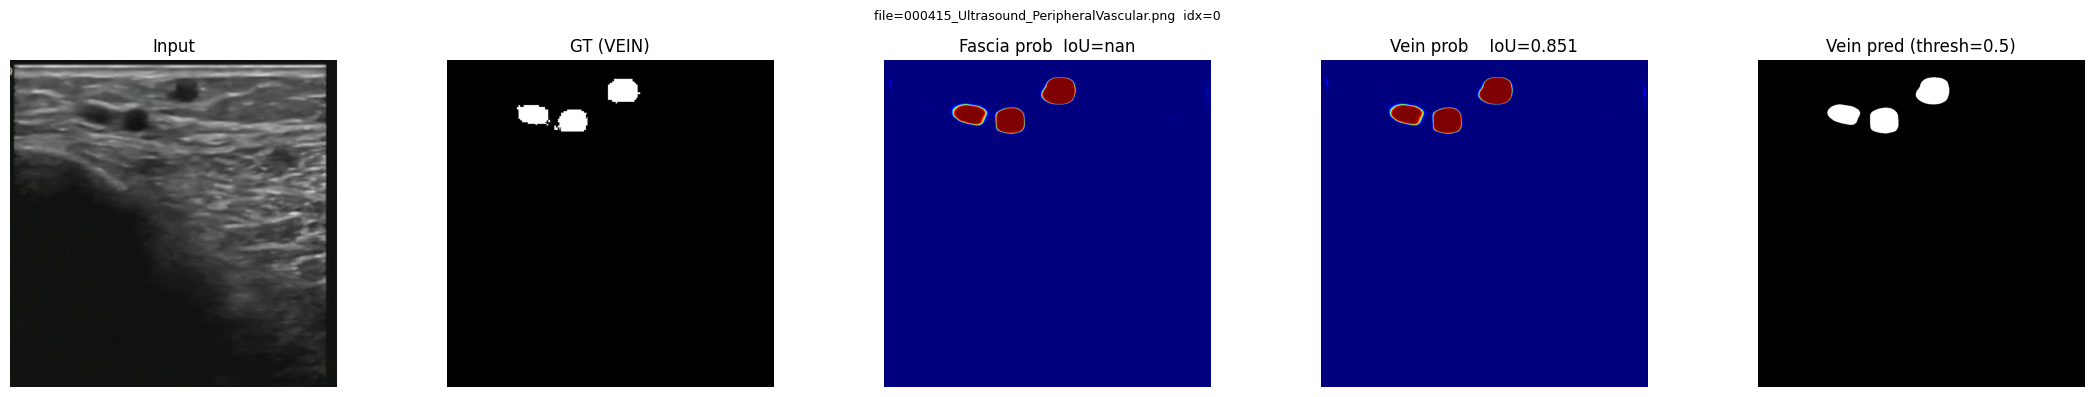

In [10]:
import matplotlib.pyplot as plt

idx          = 0
use_vein_ann = True  # False = pick from fascia test set

ann_list = vein_test_anns if use_vein_ann else fascia_test_anns
ann      = ann_list[idx]

pil_img = Image.open(TEST_IMG_DIR  / ann['file_name']).convert('RGB')
H, W    = pil_img.size[1], pil_img.size[0]
gt_bin  = (np.array(Image.open(TEST_MASK_DIR / ann['mask_file']).convert('L')) == 1).astype(np.uint8)

out_f, _ = infer_grounding(pil_img, FASCIA_PROMPT)
out_v, _ = infer_grounding(pil_img, VEIN_PROMPT)

prob_f = grounding_to_prob(out_f, H, W)
prob_v = grounding_to_prob(out_v, H, W)

pred_f = (prob_f > 0.5).astype(np.uint8)
pred_v = (prob_v > 0.5).astype(np.uint8)

cat_name = 'VEIN' if use_vein_ann else 'FASCIA'
gt_iou_f = int((pred_f & gt_bin).sum()) / (int((pred_f | gt_bin).sum()) + 1e-6) if not use_vein_ann else float('nan')
gt_iou_v = int((pred_v & gt_bin).sum()) / (int((pred_v | gt_bin).sum()) + 1e-6) if use_vein_ann else float('nan')

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes[0].imshow(pil_img);                               axes[0].set_title('Input')
axes[1].imshow(gt_bin,   cmap='gray');                 axes[1].set_title(f'GT ({cat_name})')
axes[2].imshow(prob_f,   cmap='jet', vmin=0, vmax=1); axes[2].set_title(f'Fascia prob  IoU={gt_iou_f:.3f}')
axes[3].imshow(prob_v,   cmap='jet', vmin=0, vmax=1); axes[3].set_title(f'Vein prob    IoU={gt_iou_v:.3f}')
axes[4].imshow(pred_v,   cmap='gray');                 axes[4].set_title('Vein pred (thresh=0.5)')
for ax in axes: ax.axis('off')
plt.suptitle(f'file={ann["file_name"]}  idx={idx}', fontsize=9)
plt.tight_layout()
plt.show()

---
## 11 · Update app.py to use fascia+vein model

Run this cell once training is complete and you are satisfied with the results.

In [ ]:
app_path = _BASE_DIR / 'app.py'
txt = app_path.read_text(encoding='utf-8')

# Replace checkpoint directory name
old_dir = 'fascia_finetuning_v2_production'
new_dir = 'fascia_vein_finetuning'

if old_dir in txt:
    txt = txt.replace(old_dir, new_dir)
    app_path.write_text(txt, encoding='utf-8')
    print(f'app.py updated: {old_dir} -> {new_dir}')
elif new_dir in txt:
    print(f'app.py already points to {new_dir} — no change needed.')
else:
    print('WARNING: neither checkpoint directory found in app.py — check manually.')